In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class OrderState:
    product_price: float
    quantity: int
    shipping_rate: float
    discount_percent: float

    order_valid: bool
    product_cost: float
    shipping_cost: float
    discount_amount: float
    
    final_bill: float
    invoice: str

In [3]:
## validate order
def validate_order(state: OrderState):
    if state["product_price"] <= 0:
        return {"order_valid": False}

    if state["quantity"] <= 0:
        return {"order_valid": False}

    return {
        "order_valid": True}

In [4]:
## product cost
def calculate_product_cost(state: OrderState):
    product_cost = state["product_price"]*state["quantity"]
    return {"product_cost":product_cost}

In [5]:
def calculate_shipping_cost(state: OrderState):
    shipping_cost = state["shipping_rate"]*state["quantity"]
    return {
        "shipping_cost":shipping_cost
    }

In [6]:
def calculate_discount(state: OrderState):
    product_cost = (
        state["product_price"] * state["quantity"]
    )

    discount_amount = (
        product_cost
        * state["discount_percent"]
        / 100
    )

    return {
        "discount_amount": discount_amount
    }


In [7]:
def calculate_final_bill(state: OrderState):
    final_bill = (state["product_cost"]
        + state["shipping_cost"]
        - state["discount_amount"]
    )

    return {
        "final_bill": final_bill
    }


In [8]:
def generate_invoice(state: OrderState):

    invoice = f"""
=============================
          INVOICE
=============================

Product Cost : ₹{state["product_cost"]:.2f}
Shipping     : ₹{state["shipping_cost"]:.2f}
Discount     : ₹{state["discount_amount"]:.2f}

-----------------------------
Final Bill   : ₹{state["final_bill"]:.2f}
=============================
"""

    return {
        "invoice": invoice
    }


In [9]:
### graph
graph = StateGraph(OrderState)

In [10]:
## add nodes
graph.add_node("validate_order",validate_order)
graph.add_node("calculate_product_cost",calculate_product_cost)
graph.add_node("calculate_shipping_cost",calculate_shipping_cost)
graph.add_node("calculate_discount",calculate_discount)
graph.add_node("calculate_final_bill",calculate_final_bill)
graph.add_node("generate_invoice",generate_invoice)

In [11]:
## add edges
graph.add_edge(START,"validate_order")
graph.add_edge("validate_order","calculate_product_cost")
graph.add_edge("validate_order","calculate_shipping_cost")
graph.add_edge("validate_order","calculate_discount")
graph.add_edge("calculate_product_cost","calculate_final_bill")
graph.add_edge("calculate_shipping_cost","calculate_final_bill")
graph.add_edge("calculate_discount","calculate_final_bill")
graph.add_edge("calculate_final_bill","generate_invoice")
graph.add_edge("generate_invoice",END)

In [12]:
app = graph.compile()

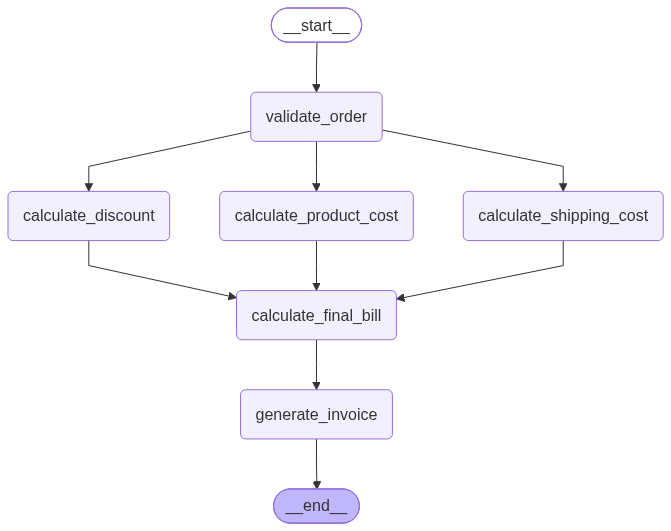

In [13]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
### Input to the workflow
initial_state = {
    "product_price":1500,
    "quantity": 17,
    "shipping_rate":48,
    "discount_percent":14
}

In [15]:
final_state = app.invoke(initial_state)

In [16]:
print(final_state)

{'product_price': 1500, 'quantity': 17, 'shipping_rate': 48, 'discount_percent': 14, 'order_valid': True, 'product_cost': 25500, 'shipping_cost': 816, 'discount_amount': 3570.0, 'final_bill': 22746.0, 'invoice': '\n=============================\n          INVOICE\n=============================\n\nProduct Cost : ₹25500.00\nShipping     : ₹816.00\nDiscount     : ₹3570.00\n\n-----------------------------\nFinal Bill   : ₹22746.00\n=============================\n'}
